In [ ]:
# import necessary packages
import pandas as pd
from cmapPy.pandasGEXpress.parse import parse
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Selecting Samples To Look At:

#### a. Selected landmark genes

In [ ]:
# read gene info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [ ]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]
lm_gene_id.head()

0      780
1     7849
25    6193
43      23
49    9552
Name: pr_gene_id, dtype: object

In [ ]:
# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### b. Selected gene signatures ids

In [ ]:
# read the gene signature info
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_sig_info.txt"
sig_info = pd.read_csv(file_path, sep="\t", dtype=str)

# select only those of treated compounds and remove perturbagen type column as all are treated compounds
sig_info = sig_info[sig_info["pert_type"]=="trt_cp"]
sig_info.head()

,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,distil_id
4,LJP005_A375_24H:A07,BRD-K76908866,CP-724714,trt_cp,A375,10.0 um,24 h,LJP005_A375_24H_X1_B19:A07|LJP005_A375_24H_X2_...
5,LJP005_A375_24H:A08,BRD-K76908866,CP-724714,trt_cp,A375,3.33 um,24 h,LJP005_A375_24H_X1_B19:A08|LJP005_A375_24H_X2_...
6,LJP005_A375_24H:A09,BRD-K76908866,CP-724714,trt_cp,A375,1.11 um,24 h,LJP005_A375_24H_X1_B19:A09|LJP005_A375_24H_X2_...
7,LJP005_A375_24H:A10,BRD-K76908866,CP-724714,trt_cp,A375,0.37 um,24 h,LJP005_A375_24H_X1_B19:A10|LJP005_A375_24H_X2_...
8,LJP005_A375_24H:A11,BRD-K76908866,CP-724714,trt_cp,A375,0.12 um,24 h,LJP005_A375_24H_X1_B19:A11|LJP005_A375_24H_X2_...


In [ ]:
# select only the gene signature ids of the atenolol, acebutolol, and fluorouracil compounds 
# for only the MCF7 cell line
test_sig_info = sig_info[(sig_info["pert_iname"].isin(["atenolol-(+/-)", "acebutolol", "fluorouracil"])) \
                           & (sig_info["cell_id"] == "MCF7")]

# check if selected those compounds and number of samples treated for that sample
test_sig_info["pert_iname"].value_counts() 

atenolol-(+/-)    6
fluorouracil      6
acebutolol        6
Name: pert_iname, dtype: int64

In [ ]:
test_sig_info.drop(columns=["pert_type", "pert_itime"])

,sig_id,pert_id,pert_iname,cell_id,pert_idose,distil_id
41362,REP.A001_MCF7_24H:L07,BRD-A29260609,acebutolol,MCF7,10.0 um,REP.A001_MCF7_24H_X1_B27:L07|REP.A001_MCF7_24H...
41363,REP.A001_MCF7_24H:L08,BRD-A29260609,acebutolol,MCF7,3.33 um,REP.A001_MCF7_24H_X1_B27:L08|REP.A001_MCF7_24H...
41364,REP.A001_MCF7_24H:L09,BRD-A29260609,acebutolol,MCF7,1.11 um,REP.A001_MCF7_24H_X1_B27:L09|REP.A001_MCF7_24H...
41365,REP.A001_MCF7_24H:L10,BRD-A29260609,acebutolol,MCF7,0.37 um,REP.A001_MCF7_24H_X1_B27:L10|REP.A001_MCF7_24H...
41366,REP.A001_MCF7_24H:L11,BRD-A29260609,acebutolol,MCF7,0.12 um,REP.A001_MCF7_24H_X1_B27:L11|REP.A001_MCF7_24H...
41367,REP.A001_MCF7_24H:L12,BRD-A29260609,acebutolol,MCF7,0.04 um,REP.A001_MCF7_24H_X1_B27:L12|REP.A001_MCF7_24H...
49296,REP.A004_MCF7_24H:J19,BRD-K24844714,fluorouracil,MCF7,10.0 um,REP.A004_MCF7_24H_X1_B27:J19|REP.A004_MCF7_24H...
49297,REP.A004_MCF7_24H:J20,BRD-K24844714,fluorouracil,MCF7,3.33 um,REP.A004_MCF7_24H_X1_B27:J20|REP.A004_MCF7_24H...
49298,REP.A004_MCF7_24H:J21,BRD-K24844714,fluorouracil,MCF7,1.11 um,REP.A004_MCF7_24H_X1_B27:J21|REP.A004_MCF7_24H...
49299,REP.A004_MCF7_24H:J22,BRD-K24844714,fluorouracil,MCF7,0.37 um,REP.A004_MCF7_24H_X1_B27:J22|REP.A004_MCF7_24H...


In [22]:
# select only those with one dose
test_sig_info = test_sig_info[test_sig_info["pert_idose"] == "0.04 um"]
test_sig_info.drop(columns=["pert_type"])

,sig_id,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
41367,REP.A001_MCF7_24H:L12,BRD-A29260609,acebutolol,MCF7,0.04 um,24 h,REP.A001_MCF7_24H_X1_B27:L12|REP.A001_MCF7_24H...
49301,REP.A004_MCF7_24H:J24,BRD-K24844714,fluorouracil,MCF7,0.04 um,24 h,REP.A004_MCF7_24H_X1_B27:J24|REP.A004_MCF7_24H...
102150,REP.A024_MCF7_24H:B18,BRD-A20239487,atenolol-(+/-),MCF7,0.04 um,24 h,REP.A024_MCF7_24H_X1_B23:B18|REP.A024_MCF7_24H...


In [23]:
# select the gene signature ids
test_sig_ids = test_sig_info["sig_id"]

#### c. Selected only the gene signatures of interest

In [24]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# select only the landmark genes of drug compounds of interest
gene_sigs = parse(file_path, rid=lm_gene_id, cid=test_sig_ids)

# check that I selected the 978 landmark genes and drug compound samples
gene_sigs.data_df.shape

(978, 3)

In [25]:
gene_sigs.data_df.head()

cid,REP.A001_MCF7_24H:L12,REP.A004_MCF7_24H:J24,REP.A024_MCF7_24H:B18
rid,,,
780,0.689055,-1.199867,-0.249998
7849,0.376903,-1.187417,-1.146199
6193,1.103076,-0.263705,0.206859
23,0.141342,-0.179414,-0.345942
9552,0.435202,-0.796290,-0.361436


### 2. Perform Spearman Correlation

#### a. Compare acetonol to atenolol-(+/-) gene signatures

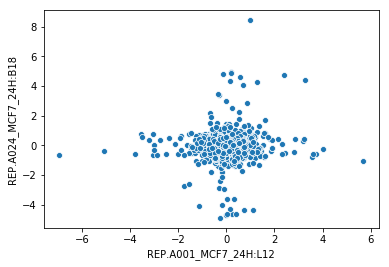

In [26]:
# make a scatterplot comparing acetonol (1st column) & atenolol-(+/-) (3rd column)
sns.scatterplot(
    x = gene_sigs.data_df.iloc[:, 0],
    y = gene_sigs.data_df.iloc[:, 2])

In [27]:
# perform a spearman correlation of the acetonol (1st column) & atenolol-(+/-) (3rd column)
stats.spearmanr(gene_sigs.data_df.iloc[:,0], gene_sigs.data_df.iloc[:, 2])

SpearmanrResult(correlation=-0.0023753112333632664, pvalue=0.940860639557148)

#### b. Compare acetonol to fluorouracil gene signatures

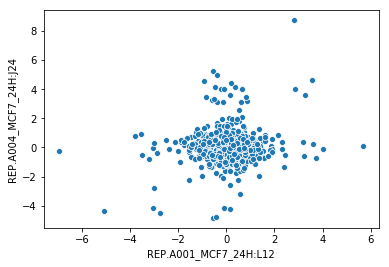

In [28]:
# make a scatterplot comparing acetonol (1st column) & fluorouracil (2nd column)
sns.scatterplot(
    x = gene_sigs.data_df.iloc[:, 0],
    y = gene_sigs.data_df.iloc[:, 1])

In [29]:
# perform a spearman correlation of the acetonol (1st column) & fluorouracil (2nd column)
stats.spearmanr(gene_sigs.data_df.iloc[:,0], gene_sigs.data_df.iloc[:, 1])

SpearmanrResult(correlation=-0.0384520611480735, pvalue=0.2295893110081457)

#### c. Compare fluorouracil to atenolol-(+/-) gene signatures

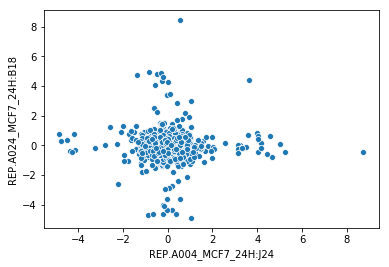

In [30]:
# make a scatterplot comparing fluorouracil (2nd column) & atenolol-(+/-) (3rd column)
sns.scatterplot(
    x = gene_sigs.data_df.iloc[:, 1],
    y = gene_sigs.data_df.iloc[:, 2])

In [31]:
# perform a spearman correlation of the fluorouracil (2nd column) & atenolol-(+/-)  (2rd column)
stats.spearmanr(gene_sigs.data_df.iloc[:,1], gene_sigs.data_df.iloc[:, 2])

SpearmanrResult(correlation=-0.06265147798720093, pvalue=0.05014583135076051)